<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = r"C:\Users\iakov\OneDrive\Desktop\ECO590\590 Bike\\"
df = pd.read_csv(file_path+"Daily_rides_data.csv")
df.head()

,date,casual,member,total_rides,casual_share,avg_ride_length_mins,avg_casual_ride_length_mins,avg_member_ride_length_mins,temp_max,temp_min,temp_mean,precip_mm,rain_any,rain_1mm,rain_5mm
0,2025-01-01,346,832,1178,0.293718,8.990864,13.314308,7.192893,10.9,3.9,7.4,4.5,1,1,0
1,2025-01-02,220,1489,1709,0.128730,6.826268,8.320846,6.605444,5.4,0.3,2.6,0.0,0,0,0
2,2025-01-03,274,1496,1770,0.154802,6.765170,8.799531,6.392566,3.2,-1.9,0.4,0.0,0,0,0
3,2025-01-04,265,1072,1337,0.198205,7.481250,9.231497,7.048587,-0.1,-2.7,-1.4,0.0,0,0,0
4,2025-01-05,217,972,1189,0.182506,6.916327,8.787102,6.498675,0.3,-3.6,-2.2,0.0,0,0,0


In [3]:
df.columns

Index(['date', 'casual', 'member', 'total_rides', 'casual_share',
       'avg_ride_length_mins', 'avg_casual_ride_length_mins',
       'avg_member_ride_length_mins', 'temp_max', 'temp_min', 'temp_mean',
       'precip_mm', 'rain_any', 'rain_1mm', 'rain_5mm'],
      dtype='object')

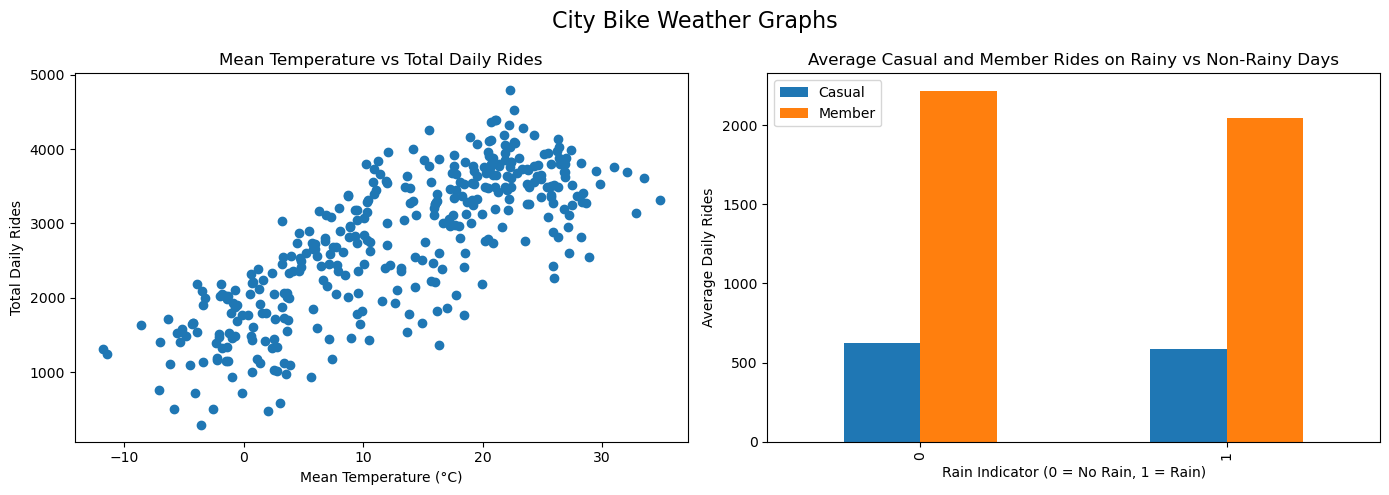

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(df['temp_mean'], df['total_rides'])
ax1.set_title('Mean Temperature vs Total Daily Rides')
ax1.set_xlabel('Mean Temperature (°C)')
ax1.set_ylabel('Total Daily Rides')

rides_by_rain = df.groupby('rain_any')[['casual', 'member']].mean()

ax2 = plt.subplot(1, 2, 2)
rides_by_rain.plot(kind='bar', ax=ax2)
ax2.set_title('Average Casual and Member Rides on Rainy vs Non-Rainy Days')
ax2.set_xlabel('Rain Indicator (0 = No Rain, 1 = Rain)')
ax2.set_ylabel('Average Daily Rides')
ax2.legend(['Casual', 'Member'])

fig.suptitle('City Bike Weather Graphs', fontsize=16)
fig.tight_layout()
plt.savefig("city_graphs_1_2.png", dpi=300, bbox_inches='tight')
plt.show()

The first graph shows a clear positive relationship between mean temperature and total daily rides. As temperature goes up, total rides generally go up too, so warmer days seem to bring more Citi Bike usage overall.

The second graph compares average casual and member rides on rainy and non-rainy days. It shows that member rides are much higher than casual rides in both cases, while both groups ride a  less on rainy days.

C:\Users\iakov\AppData\Local\Temp\ipykernel_17012\3155078113.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rain_0, rain_1], labels=['No Rain', 'Rain'])


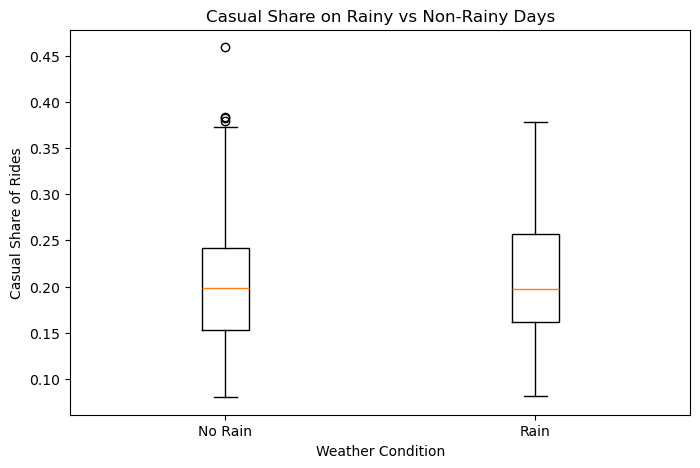

In [8]:
rain_0 = df[df['rain_any'] == 0]['casual_share']
rain_1 = df[df['rain_any'] == 1]['casual_share']

plt.figure(figsize=(8,5))
plt.boxplot([rain_0, rain_1], labels=['No Rain', 'Rain'])
plt.title('Casual Share on Rainy vs Non-Rainy Days')
plt.xlabel('Weather Condition')
plt.ylabel('Casual Share of Rides')
plt.savefig("city_graph_3.png", dpi=300, bbox_inches='tight')
plt.show()

This graph compares the distribution of casual share on rainy and non-rainy days. The two groups look fairly similar overall, although the casual share appears to be a bit lower on rainy days looking at the median line.